In [1]:
import sys

print(sys.version)
print(sys.executable)

3.12.13 | packaged by conda-forge | (main, Mar  5 2026, 16:50:00) [GCC 14.3.0]
/home/chitta/.conda/envs/emotion-nlp/bin/python


In [2]:
from datasets import load_dataset

dataset = load_dataset("roskoN/dailydialog")

/home/chitta/.conda/envs/emotion-nlp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


RuntimeError: Dataset scripts are no longer supported, but found dailydialog.py

In [3]:
pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 6.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 2.8 MB/s  0:00:00m 3.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]━━━━━━━ 2/3 [ipywidgets]
Note: you may need to restart the kernel to use updated packages.


In [1]:
from datasets import load_dataset

dataset = load_dataset(
    "parquet",
    data_files={
        "train": "hf://datasets/roskoN/dailydialog/data/train-*.parquet",
        "validation": "hf://datasets/roskoN/dailydialog/data/validation-*.parquet",
        "test": "hf://datasets/roskoN/dailydialog/data/test-*.parquet",
    }
)

dataset

ValueError: At least one valid data file must be specified, all the data_files are invalid: {'train': [], 'validation': [], 'test': []}

In [2]:
from datasets import load_dataset

dataset = load_dataset(
    "roskoN/dailydialog",
    revision="refs/convert/parquet"
)

dataset

full/train/0000.parquet: reconstructing file:   0%|          |  0.00B / 3.67MB            

full/train/0000.parquet: downloading bytes:           |  0.00B            

0000.parquet:   0%|          | 0.00/340k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/337k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'acts', 'emotions', 'utterances'],
        num_rows: 11118
    })
    validation: Dataset({
        features: ['id', 'acts', 'emotions', 'utterances'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['id', 'acts', 'emotions', 'utterances'],
        num_rows: 1000
    })
})

# DailyDialog Exploratory Data Analysis

This notebook explores DailyDialog as a candidate primary dataset for the
Context-Aware Emotion Dynamics and Forecasting project.

## 1. Dataset Inspection

In [4]:
dataset["train"].features

{'id': Value('string'),
 'acts': List(Value('int8')),
 'emotions': List(Value('int8')),
 'utterances': List(Value('string'))}

In [5]:
sample = dataset["train"][0]
sample

{'id': 'a438b751ab9997cdb35f07bfe3dfb010b96365f4762d77f87e5f41290ff61c3d_0',
 'acts': [3, 4, 2, 2, 2, 3, 4, 1, 3, 4],
 'emotions': [0, 0, 0, 0, 0, 0, 4, 4, 4, 4],
 'utterances': ['Say , Jim , how about going for a few beers after dinner ?',
  'You know that is tempting but is really not good for our fitness .',
  'What do you mean ? It will help us to relax .',
  "Do you really think so ? I don't . It will just make us fat and act silly . Remember last time ?",
  "I guess you are right.But what shall we do ? I don't feel like sitting at home .",
  'I suggest a walk over to the gym where we can play singsong and meet some of our friends .',
  "That's a good idea . I hear Mary and Sally often go there to play pingpong.Perhaps we can make a foursome with them .",
  'Sounds great to me ! If they are willing , we could ask them to go dancing with us.That is excellent exercise and fun , too .',
  "Good.Let ' s go now .",
  'All right .']}

In [6]:
for i, (utterance, emotion, act) in enumerate(
    zip(sample["utterances"], sample["emotions"], sample["acts"])
):
    print(f"Turn {i + 1}")
    print(f"Utterance: {utterance}")
    print(f"Emotion:  {emotion}")
    print(f"Act:      {act}")
    print()

Turn 1
Utterance: Say , Jim , how about going for a few beers after dinner ?
Emotion:  0
Act:      3

Turn 2
Utterance: You know that is tempting but is really not good for our fitness .
Emotion:  0
Act:      4

Turn 3
Utterance: What do you mean ? It will help us to relax .
Emotion:  0
Act:      2

Turn 4
Utterance: Do you really think so ? I don't . It will just make us fat and act silly . Remember last time ?
Emotion:  0
Act:      2

Turn 5
Utterance: I guess you are right.But what shall we do ? I don't feel like sitting at home .
Emotion:  0
Act:      2

Turn 6
Utterance: I suggest a walk over to the gym where we can play singsong and meet some of our friends .
Emotion:  0
Act:      3

Turn 7
Utterance: That's a good idea . I hear Mary and Sally often go there to play pingpong.Perhaps we can make a foursome with them .
Emotion:  4
Act:      4

Turn 8
Utterance: Sounds great to me ! If they are willing , we could ask them to go dancing with us.That is excellent exercise and fun , to

readme.txt

Here are some explanations about the files:

1) dialogues_text.txt: The DailyDialog dataset which contains 11318 transcribed dialogues.
2) dialogues_topic.txt: Each line of dialogues_topic.txt corresponds to the topic of same line in dialogues_text.txt.
                        The representation of the topic number: {1: Ordinary Life, 2: School Life, 3: Culture & Education,
                        4: Attitude & Emotion, 5: Relationship, 6: Tourism , 7: Health, 8: Work, 9: Politics, 10: Finance}
3) dialogues_act.txt: Each line of dialogues_act.txt corresponds to the act of same line in dialogues_text.txt.
                      The representation of the act number: { 1: inform，2: question, 3: directive, 4: commissive }
4) dialogues_emotion.txt: Each line of dialogues_emotion.txt corresponds to the emotion of same line in dialogues_text.txt.
                          The representation of the emotion number: { 0: no emotion, 1: anger, 2: disgust, 3: fear, 4: happiness, 5: sadness, 6: surprise}
5) train.zip, validation.zip and test.zip are the different segmentation of the whole dataset. 

In [9]:
EMOTION_LABELS = {
    0: "no emotion",
    1: "anger",
    2: "disgust",
    3: "fear",
    4: "happiness",
    5: "sadness",
    6: "surprise",
}

In [8]:
ACT_LABELS = {
    1: "inform",
    2: "question",
    3: "directive",
    4: "commissive",
}

In [11]:
for split_name, split_data in dataset.items():
    mismatches = 0

    for dialogue in split_data:
        n_utterances = len(dialogue["utterances"])
        n_emotions = len(dialogue["emotions"])
        n_acts = len(dialogue["acts"])

        if not (n_utterances == n_emotions == n_acts):
            mismatches += 1

    print(f"{split_name}: {mismatches} mismatched dialogues")

train: 0 mismatched dialogues
validation: 0 mismatched dialogues
test: 0 mismatched dialogues


In [12]:
for split_name, split_data in dataset.items():
    empty_dialogues = 0
    empty_utterances = 0

    for dialogue in split_data:
        if len(dialogue["utterances"]) == 0:
            empty_dialogues += 1

        for utterance in dialogue["utterances"]:
            if not utterance.strip():
                empty_utterances += 1

    print(
        f"{split_name}: "
        f"{empty_dialogues} empty dialogues, "
        f"{empty_utterances} empty utterances"
    )

train: 0 empty dialogues, 0 empty utterances
validation: 0 empty dialogues, 0 empty utterances
test: 0 empty dialogues, 0 empty utterances


In [13]:
for split_name, split_data in dataset.items():
    n_dialogues = len(split_data)
    n_utterances = sum(
        len(dialogue["utterances"])
        for dialogue in split_data
    )

    print(
        f"{split_name}: "
        f"{n_dialogues:,} dialogues, "
        f"{n_utterances:,} utterances"
    )

train: 11,118 dialogues, 87,170 utterances
validation: 1,000 dialogues, 8,069 utterances
test: 1,000 dialogues, 7,740 utterances


In [14]:
total_dialogues = sum(len(split_data) for split_data in dataset.values())

total_utterances = sum(
    len(dialogue["utterances"])
    for split_data in dataset.values()
    for dialogue in split_data
)

print(f"Total dialogues:  {total_dialogues:,}")
print(f"Total utterances: {total_utterances:,}")

Total dialogues:  13,118
Total utterances: 102,979


## 3. Emotion Distribution

DailyDialog contains seven emotion labels: no emotion, anger, disgust,
fear, happiness, sadness, and surprise. We examine their frequencies
across the full dataset and individual splits to assess class imbalance.

In [15]:
from collections import Counter

emotion_counts = Counter()

for split_data in dataset.values():
    for dialogue in split_data:
        emotion_counts.update(dialogue["emotions"])

emotion_counts

Counter({0: 85572, 4: 12885, 6: 1823, 5: 1150, 1: 1022, 2: 353, 3: 174})

In [16]:
for label_id, count in sorted(emotion_counts.items()):
    label = EMOTION_LABELS[label_id]
    percentage = count / total_utterances * 100

    print(f"{label:12} {count:>7,}  ({percentage:5.2f}%)")

no emotion    85,572  (83.10%)
anger          1,022  ( 0.99%)
disgust          353  ( 0.34%)
fear             174  ( 0.17%)
happiness     12,885  (12.51%)
sadness        1,150  ( 1.12%)
surprise       1,823  ( 1.77%)


In [17]:
for split_name, split_data in dataset.items():
    counts = Counter()

    for dialogue in split_data:
        counts.update(dialogue["emotions"])

    print(f"\n{split_name.upper()}")

    for label_id in sorted(EMOTION_LABELS):
        count = counts[label_id]
        percentage = count / sum(counts.values()) * 100

        print(
            f"{EMOTION_LABELS[label_id]:12} "
            f"{count:>7,}  "
            f"({percentage:5.2f}%)"
        )


TRAIN
no emotion    72,143  (82.76%)
anger            827  ( 0.95%)
disgust          303  ( 0.35%)
fear             146  ( 0.17%)
happiness     11,182  (12.83%)
sadness          969  ( 1.11%)
surprise       1,600  ( 1.84%)

VALIDATION
no emotion     7,108  (88.09%)
anger             77  ( 0.95%)
disgust            3  ( 0.04%)
fear              11  ( 0.14%)
happiness        684  ( 8.48%)
sadness           79  ( 0.98%)
surprise         107  ( 1.33%)

TEST
no emotion     6,321  (81.67%)
anger            118  ( 1.52%)
disgust           47  ( 0.61%)
fear              17  ( 0.22%)
happiness      1,019  (13.17%)
sadness          102  ( 1.32%)
surprise         116  ( 1.50%)


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

emotion_df = pd.DataFrame([
    {
        "emotion": EMOTION_LABELS[label_id],
        "count": count,
        "percentage": count / total_utterances * 100,
    }
    for label_id, count in sorted(emotion_counts.items())
])

emotion_df

,emotion,count,percentage
0,no emotion,85572,83.096554
1,anger,1022,0.992435
2,disgust,353,0.342788
3,fear,174,0.168966
4,happiness,12885,12.512260
5,sadness,1150,1.116733
6,surprise,1823,1.770264


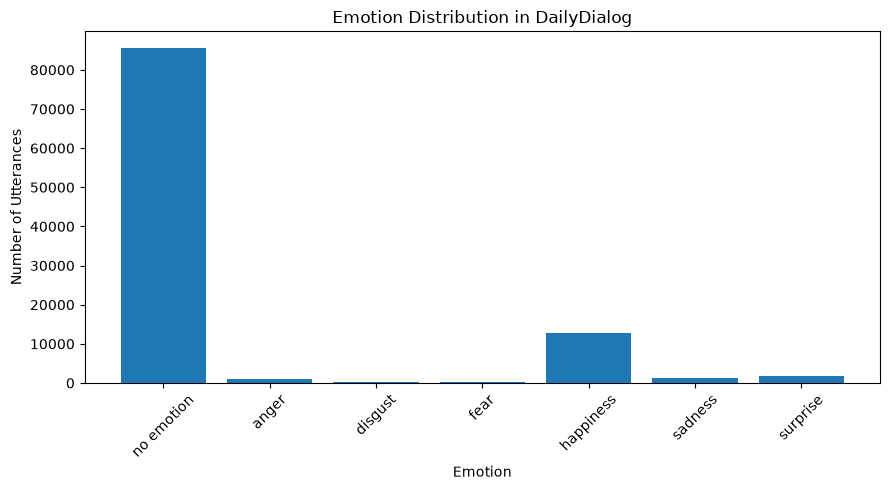

In [19]:
plt.figure(figsize=(9, 5))

plt.bar(emotion_df["emotion"], emotion_df["count"])

plt.title("Emotion Distribution in DailyDialog")
plt.xlabel("Emotion")
plt.ylabel("Number of Utterances")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 4. Dialogue-Level Emotion Dynamics

To assess DailyDialog's suitability for emotion trajectory modeling and
forecasting, we examine how emotions evolve within individual conversations.

In [20]:
total_dialogues = 0
all_no_emotion_dialogues = 0
emotional_dialogues = 0

for split_data in dataset.values():
    for dialogue in split_data:
        total_dialogues += 1

        emotions = dialogue["emotions"]

        if all(emotion == 0 for emotion in emotions):
            all_no_emotion_dialogues += 1
        else:
            emotional_dialogues += 1

print(f"Total dialogues:          {total_dialogues:,}")
print(f"All-no-emotion dialogues: {all_no_emotion_dialogues:,}")
print(f"Emotional dialogues:      {emotional_dialogues:,}")

print(
    f"\nAll-no-emotion: "
    f"{all_no_emotion_dialogues / total_dialogues * 100:.2f}%"
)

print(
    f"Contains emotion: "
    f"{emotional_dialogues / total_dialogues * 100:.2f}%"
)

Total dialogues:          13,118
All-no-emotion dialogues: 6,247
Emotional dialogues:      6,871

All-no-emotion: 47.62%
Contains emotion: 52.38%


In [21]:
transition_counts = []

for split_data in dataset.values():
    for dialogue in split_data:
        emotions = dialogue["emotions"]

        transitions = sum(
            current != previous
            for previous, current in zip(emotions, emotions[1:])
        )

        transition_counts.append(transitions)

In [22]:
import numpy as np

transition_counts = np.array(transition_counts)

print(f"Mean transitions/dialogue:   {transition_counts.mean():.2f}")
print(f"Median transitions/dialogue: {np.median(transition_counts):.0f}")
print(f"Maximum transitions:         {transition_counts.max()}")

print(
    f"Dialogues with 0 transitions: "
    f"{(transition_counts == 0).sum():,} "
    f"({(transition_counts == 0).mean() * 100:.2f}%)"
)

print(
    f"Dialogues with ≥1 transition: "
    f"{(transition_counts >= 1).sum():,} "
    f"({(transition_counts >= 1).mean() * 100:.2f}%)"
)

Mean transitions/dialogue:   1.23
Median transitions/dialogue: 0
Maximum transitions:         16
Dialogues with 0 transitions: 6,686 (50.97%)
Dialogues with ≥1 transition: 6,432 (49.03%)


In [23]:
from collections import Counter

transition_distribution = Counter(transition_counts)

for n_transitions, n_dialogues in sorted(transition_distribution.items()):
    print(
        f"{n_transitions:2} transitions: "
        f"{n_dialogues:5,} dialogues "
        f"({n_dialogues / total_dialogues * 100:5.2f}%)"
    )

 0 transitions: 6,686 dialogues (50.97%)
 1 transitions: 2,374 dialogues (18.10%)
 2 transitions: 1,707 dialogues (13.01%)
 3 transitions: 1,040 dialogues ( 7.93%)
 4 transitions:   504 dialogues ( 3.84%)
 5 transitions:   325 dialogues ( 2.48%)
 6 transitions:   200 dialogues ( 1.52%)
 7 transitions:   125 dialogues ( 0.95%)
 8 transitions:    62 dialogues ( 0.47%)
 9 transitions:    44 dialogues ( 0.34%)
10 transitions:    25 dialogues ( 0.19%)
11 transitions:    11 dialogues ( 0.08%)
12 transitions:     9 dialogues ( 0.07%)
13 transitions:     4 dialogues ( 0.03%)
14 transitions:     1 dialogues ( 0.01%)
16 transitions:     1 dialogues ( 0.01%)


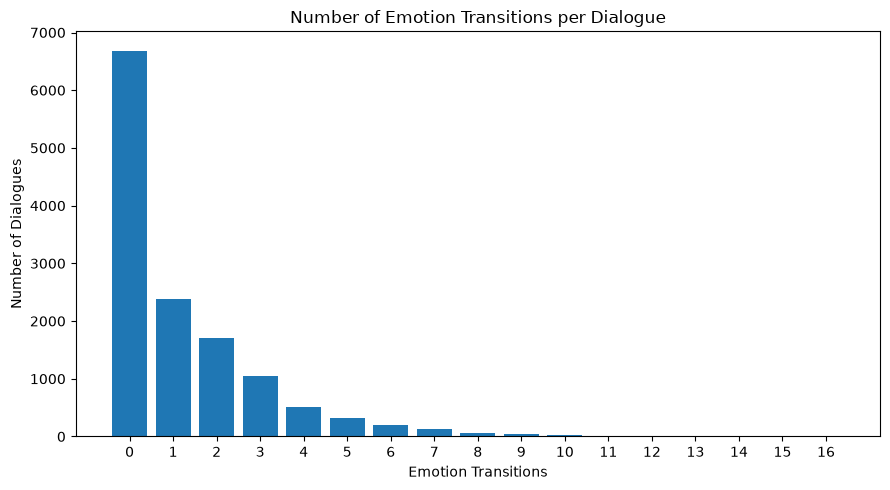

In [24]:
plt.figure(figsize=(9, 5))

plt.bar(
    transition_distribution.keys(),
    transition_distribution.values()
)

plt.title("Number of Emotion Transitions per Dialogue")
plt.xlabel("Emotion Transitions")
plt.ylabel("Number of Dialogues")
plt.xticks(range(max(transition_distribution) + 1))

plt.tight_layout()
plt.show()

In [25]:
import numpy as np

n_emotions = len(EMOTION_LABELS)

transition_matrix = np.zeros(
    (n_emotions, n_emotions),
    dtype=int
)

for split_data in dataset.values():
    for dialogue in split_data:
        emotions = dialogue["emotions"]

        for current_emotion, next_emotion in zip(
            emotions,
            emotions[1:]
        ):
            transition_matrix[current_emotion, next_emotion] += 1

In [26]:
emotion_names = [
    EMOTION_LABELS[i]
    for i in range(n_emotions)
]

transition_df = pd.DataFrame(
    transition_matrix,
    index=emotion_names,
    columns=emotion_names
)

transition_df
#Rows mean current emotion, columns mean next emotion.

,no emotion,anger,disgust,fear,happiness,sadness,surprise
no emotion,67606,677,223,125,5683,887,1401
anger,686,108,3,1,11,40,17
disgust,238,5,42,0,5,2,10
fear,136,0,0,5,8,0,8
happiness,3196,8,11,7,5898,18,169
sadness,789,34,1,1,45,65,43
surprise,1346,23,11,6,179,24,60


In [27]:
transition_probabilities = transition_matrix / transition_matrix.sum(
    axis=1,
    keepdims=True
)

transition_prob_df = pd.DataFrame(
    transition_probabilities,
    index=emotion_names,
    columns=emotion_names
)

transition_prob_df.round(3)

,no emotion,anger,disgust,fear,happiness,sadness,surprise
no emotion,0.883,0.009,0.003,0.002,0.074,0.012,0.018
anger,0.792,0.125,0.003,0.001,0.013,0.046,0.020
disgust,0.788,0.017,0.139,0.000,0.017,0.007,0.033
fear,0.866,0.000,0.000,0.032,0.051,0.000,0.051
happiness,0.343,0.001,0.001,0.001,0.634,0.002,0.018
sadness,0.807,0.035,0.001,0.001,0.046,0.066,0.044
surprise,0.816,0.014,0.007,0.004,0.109,0.015,0.036


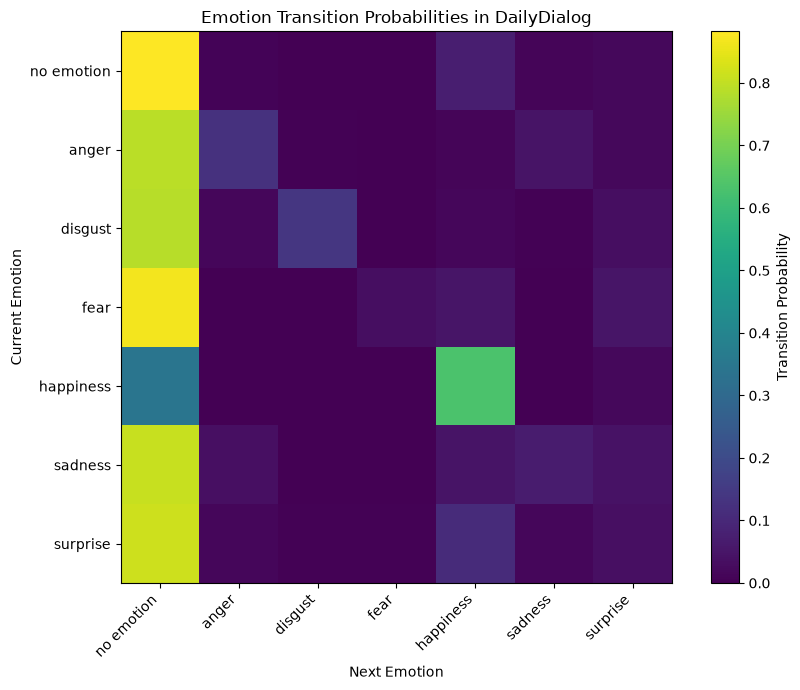

In [28]:
fig, ax = plt.subplots(figsize=(9, 7))

image = ax.imshow(transition_prob_df.values)

ax.set_xticks(range(n_emotions))
ax.set_yticks(range(n_emotions))

ax.set_xticklabels(emotion_names, rotation=45, ha="right")
ax.set_yticklabels(emotion_names)

ax.set_xlabel("Next Emotion")
ax.set_ylabel("Current Emotion")
ax.set_title("Emotion Transition Probabilities in DailyDialog")

fig.colorbar(image, ax=ax, label="Transition Probability")

plt.tight_layout()
plt.show()

In [29]:
change_matrix = transition_matrix.copy()

np.fill_diagonal(change_matrix, 0)

change_df = pd.DataFrame(
    change_matrix,
    index=emotion_names,
    columns=emotion_names
)

change_df

,no emotion,anger,disgust,fear,happiness,sadness,surprise
no emotion,0,677,223,125,5683,887,1401
anger,686,0,3,1,11,40,17
disgust,238,5,0,0,5,2,10
fear,136,0,0,0,8,0,8
happiness,3196,8,11,7,0,18,169
sadness,789,34,1,1,45,0,43
surprise,1346,23,11,6,179,24,0


In [30]:
total_changes = change_matrix.sum()

print(f"Total emotion changes: {total_changes:,}")

Total emotion changes: 16,077


In [31]:
transition_counts.sum()

np.int64(16077)

In [32]:
changes = []

for current in range(n_emotions):
    for next_emotion in range(n_emotions):

        if current == next_emotion:
            continue

        count = change_matrix[current, next_emotion]

        changes.append({
            "from": EMOTION_LABELS[current],
            "to": EMOTION_LABELS[next_emotion],
            "count": count,
            "percentage": count / total_changes * 100
        })

changes_df = pd.DataFrame(changes)

changes_df = changes_df.sort_values(
    "count",
    ascending=False
).reset_index(drop=True)

changes_df.head(15)

,from,to,count,percentage
0,no emotion,happiness,5683,35.348635
1,happiness,no emotion,3196,19.879331
2,no emotion,surprise,1401,8.714312
3,surprise,no emotion,1346,8.372209
4,no emotion,sadness,887,5.517198
5,sadness,no emotion,789,4.907632
6,anger,no emotion,686,4.266965
7,no emotion,anger,677,4.210985
8,disgust,no emotion,238,1.480376
9,no emotion,disgust,223,1.387075


In [33]:
emotion_diversity = []

for split_data in dataset.values():
    for dialogue in split_data:
        n_unique = len(set(dialogue["emotions"]))
        emotion_diversity.append(n_unique)

emotion_diversity = np.array(emotion_diversity)

diversity_distribution = Counter(emotion_diversity)

for n_emotions_present, n_dialogues in sorted(diversity_distribution.items()):
    print(
        f"{n_emotions_present} unique emotion(s): "
        f"{n_dialogues:,} dialogues "
        f"({n_dialogues / total_dialogues * 100:.2f}%)"
    )

1 unique emotion(s): 6,686 dialogues (50.97%)
2 unique emotion(s): 5,327 dialogues (40.61%)
3 unique emotion(s): 995 dialogues (7.58%)
4 unique emotion(s): 107 dialogues (0.82%)
5 unique emotion(s): 3 dialogues (0.02%)


In [34]:
dialogue_lengths = []

for split_data in dataset.values():
    for dialogue in split_data:
        dialogue_lengths.append(len(dialogue["utterances"]))

dialogue_lengths = np.array(dialogue_lengths)

print(f"Mean:   {dialogue_lengths.mean():.2f} turns")
print(f"Median: {np.median(dialogue_lengths):.0f} turns")
print(f"Min:    {dialogue_lengths.min()} turns")
print(f"Max:    {dialogue_lengths.max()} turns")

for percentile in [25, 75, 90, 95, 99]:
    print(
        f"{percentile}th percentile: "
        f"{np.percentile(dialogue_lengths, percentile):.0f} turns"
    )

Mean:   7.85 turns
Median: 7 turns
Min:    2 turns
Max:    35 turns
25th percentile: 4 turns
75th percentile: 10 turns
90th percentile: 13 turns
95th percentile: 15 turns
99th percentile: 20 turns


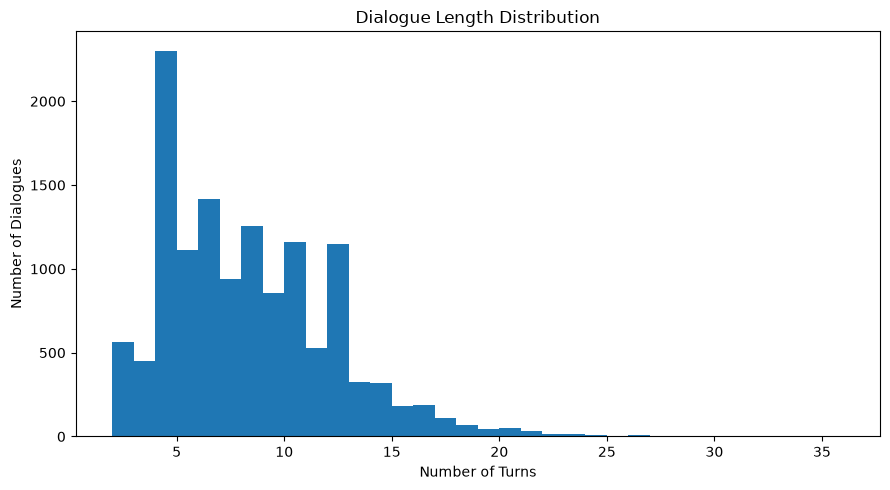

In [35]:
plt.figure(figsize=(9, 5))

plt.hist(dialogue_lengths, bins=range(
    dialogue_lengths.min(),
    dialogue_lengths.max() + 2
))

plt.title("Dialogue Length Distribution")
plt.xlabel("Number of Turns")
plt.ylabel("Number of Dialogues")

plt.tight_layout()
plt.show()

In [36]:
utterance_lengths = []

for split_data in dataset.values():
    for dialogue in split_data:
        for utterance in dialogue["utterances"]:
            utterance_lengths.append(len(utterance.split()))

utterance_lengths = np.array(utterance_lengths)

print(f"Mean:   {utterance_lengths.mean():.2f} words")
print(f"Median: {np.median(utterance_lengths):.0f} words")
print(f"Min:    {utterance_lengths.min()} words")
print(f"Max:    {utterance_lengths.max()} words")

for percentile in [25, 75, 90, 95, 99]:
    print(
        f"{percentile}th percentile: "
        f"{np.percentile(utterance_lengths, percentile):.0f} words"
    )

Mean:   13.61 words
Median: 11 words
Min:    1 words
Max:    278 words
25th percentile: 7 words
75th percentile: 17 words
90th percentile: 26 words
95th percentile: 33 words
99th percentile: 51 words


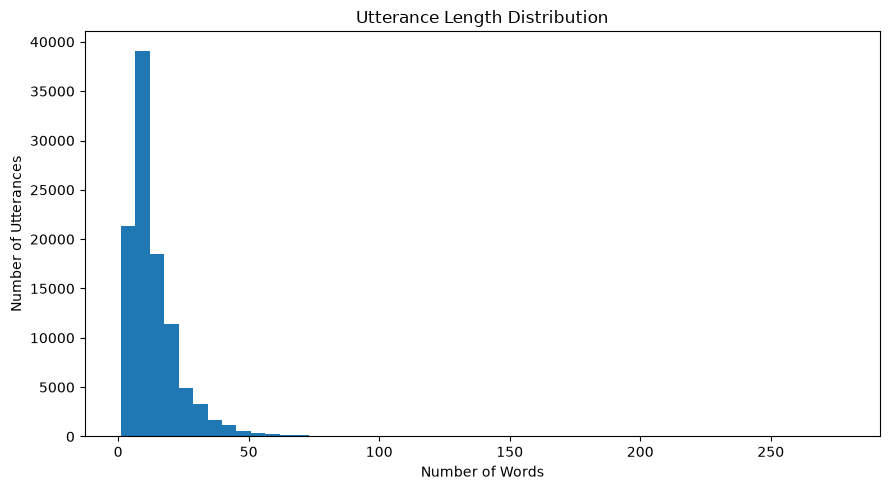

In [37]:
plt.figure(figsize=(9, 5))

plt.hist(utterance_lengths, bins=50)

plt.title("Utterance Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Utterances")

plt.tight_layout()
plt.show()

In [38]:
longest_utterances = []

for split_name, split_data in dataset.items():
    for dialogue in split_data:
        for turn_id, utterance in enumerate(dialogue["utterances"]):
            longest_utterances.append({
                "split": split_name,
                "dialogue_id": dialogue["id"],
                "turn_id": turn_id,
                "words": len(utterance.split()),
                "utterance": utterance
            })

longest_utterances = sorted(
    longest_utterances,
    key=lambda x: x["words"],
    reverse=True
)

for item in longest_utterances[:10]:
    print(
        f'{item["words"]} words | '
        f'{item["split"]} | '
        f'turn {item["turn_id"]}'
    )
    print(item["utterance"])
    print("-" * 80)

278 words | train | turn 1
I have had an incredible boss , who was my direct supervisor during the last year of my coop work experience . A-bout two months after I began working for her , she really let me spread my wings . She encouraged me to work independently , because she said she had come to trust my judgment and commitment . So I was able to move forward on projects without having to check in with her every day . Of course , I made certain that she knew what I had accomplished on a daily and weekly basis because I gave her summary reports , although she didn't specifically ask me to . Without her support and encouragement , I don't think I would have felt confident enough to have written up a proposal suggesting that the department change a process that had been in place for a long time . But she was open to suggestions , so long as employees could back them up with research and facts . When I submitted my suggestion , she reviewed it and told me where she thought it needed more

In [39]:
forecast_targets = Counter()

total_forecast_examples = 0
change_forecast_examples = 0
same_forecast_examples = 0

for split_data in dataset.values():
    for dialogue in split_data:
        emotions = dialogue["emotions"]

        for current, next_emotion in zip(
            emotions,
            emotions[1:]
        ):
            total_forecast_examples += 1
            forecast_targets[next_emotion] += 1

            if current == next_emotion:
                same_forecast_examples += 1
            else:
                change_forecast_examples += 1

print(f"Total forecasting examples: {total_forecast_examples:,}")
print(
    f"Same-state targets: {same_forecast_examples:,} "
    f"({same_forecast_examples / total_forecast_examples * 100:.2f}%)"
)
print(
    f"Change targets:     {change_forecast_examples:,} "
    f"({change_forecast_examples / total_forecast_examples * 100:.2f}%)"
)

Total forecasting examples: 89,861
Same-state targets: 73,784 (82.11%)
Change targets:     16,077 (17.89%)


In [40]:
for label_id in sorted(EMOTION_LABELS):
    count = forecast_targets[label_id]

    print(
        f"{EMOTION_LABELS[label_id]:12} "
        f"{count:>7,} "
        f"({count / total_forecast_examples * 100:5.2f}%)"
    )

no emotion    73,997 (82.35%)
anger            855 ( 0.95%)
disgust          291 ( 0.32%)
fear             145 ( 0.16%)
happiness     11,829 (13.16%)
sadness        1,036 ( 1.15%)
surprise       1,708 ( 1.90%)


In [41]:
majority_baseline_accuracy = (
    forecast_targets[0] / total_forecast_examples
)

print(
    f"Always no_emotion: "
    f"{majority_baseline_accuracy * 100:.2f}%"
)

Always no_emotion: 82.35%


In [42]:
persistence_baseline_accuracy = (
    same_forecast_examples / total_forecast_examples
)

print(
    f"Predict current emotion again: "
    f"{persistence_baseline_accuracy * 100:.2f}%"
)

Predict current emotion again: 82.11%
